# CS6220 HW1
## Elliot Wolf

In [1]:
# steps taken from: https://archive.ics.uci.edu/dataset/53/iris

from ucimlrepo import fetch_ucirepo 

# fetch dataset 
iris = fetch_ucirepo(id=53) 
  
# data (as pandas dataframes) 
X = iris.data.features 
y = iris.data.targets 
  
  
# variable information 
print(iris.variables) 

           name     role         type demographic  \
0  sepal length  Feature   Continuous        None   
1   sepal width  Feature   Continuous        None   
2  petal length  Feature   Continuous        None   
3   petal width  Feature   Continuous        None   
4         class   Target  Categorical        None   

                                         description units missing_values  
0                                                NaN    cm             no  
1                                                NaN    cm             no  
2                                                NaN    cm             no  
3                                                NaN    cm             no  
4  class of iris plant: Iris Setosa, Iris Versico...   NaN             no  


## Scatterplots (or pairs plots) of the Iris Dataset

The scatterplots below show some interesting trends, and we can already see how we may be able to identify flowers by sepal/petal length. Setosa tends to have the smallest petal length and width, followed by versicolor, then virginica. Setosa also tends to have the smallest sepal length out of the three, while versicolor and virginica have similar sepal lengths.

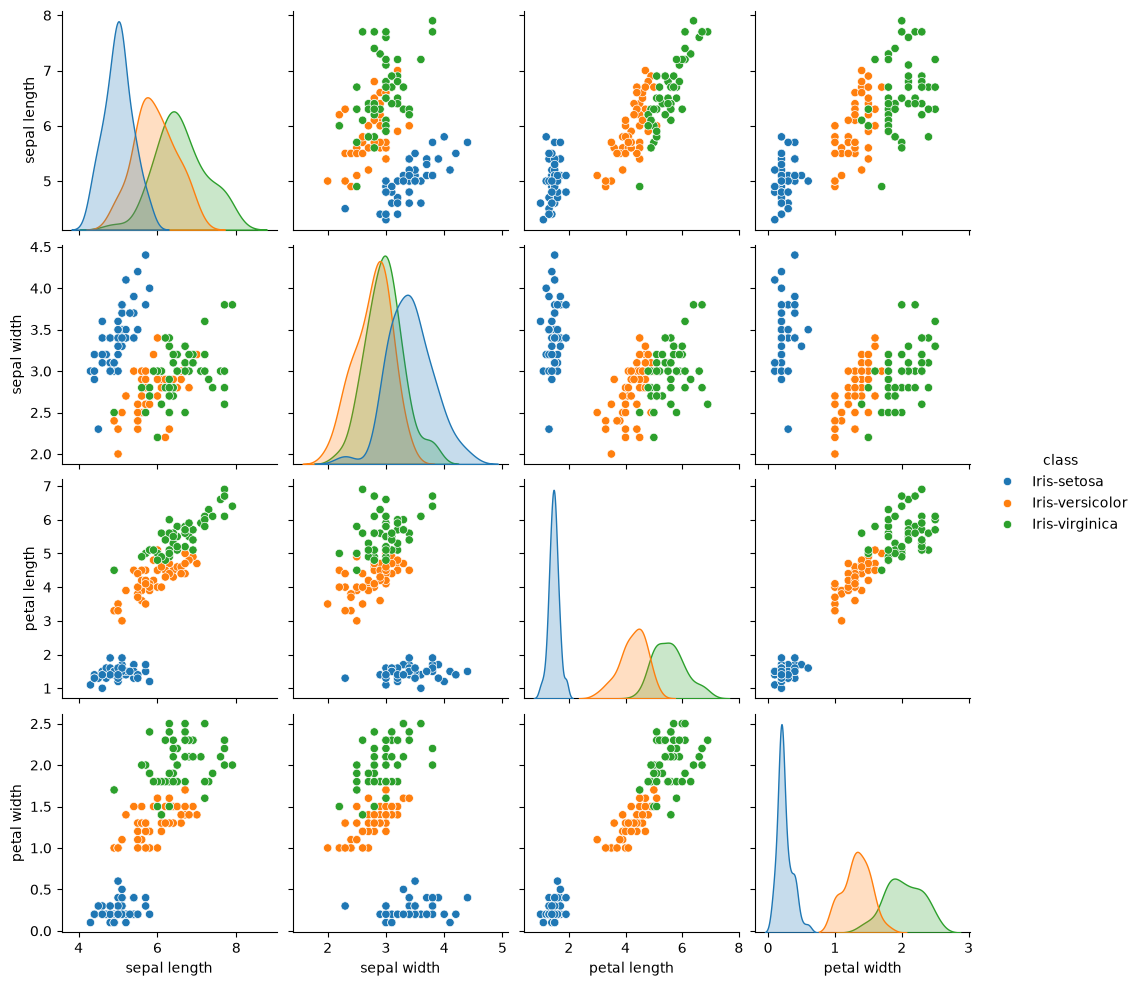

In [2]:
# https://www.geeksforgeeks.org/python/python-seaborn-pairplot-method/
import seaborn
import matplotlib.pyplot as plt

seaborn.pairplot(iris.data.original, hue="class")
plt.show()

## Split into Train/Test data

I split the data into 80% train and 20% test, as the instructions recommend.

In [3]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=0)

## Scikit-learn Pipeline (KNN Implementation)

In [4]:
# https://scikit-learn.org/stable/modules/generated/sklearn.pipeline.Pipeline.html

from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.neighbors import KNeighborsClassifier

# Creating a pipeline, scaling variables and implementing nearest neighbor classification
pipe = Pipeline([('scaler', StandardScaler()), ('knn', KNeighborsClassifier(n_neighbors=5))])


### Train the model on the training set

When implementing the %%time function here and during the testing portion, I asked Claude for the simplest way to record runtime for a code chunk. I stuck with %%time over importing the time package.

In [5]:
%%time
# Train model on the training data
pipe.fit(X_train, y_train)

CPU times: user 8.15 ms, sys: 2.01 ms, total: 10.2 ms
Wall time: 14.5 ms


/Users/apple/Desktop/CS6220/cs6220-hw/.venv/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('knn', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['Iris-setosa','Iris-versicolor','Iris-virginica']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['sepal length','sepal width','petal length','petal width']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


### Evaluating the model on the test data

In [6]:
%%time
# Evaluate the model on the test data
y_pred = pipe.predict(X_test)

CPU times: user 1.37 ms, sys: 480 μs, total: 1.85 ms
Wall time: 1.4 ms


### Model Accuracy
Our model was 100% accurate when using an n_neighbors of 5.

In [7]:
# Model accuracy
from sklearn.metrics import accuracy_score

print(accuracy_score(y_test, y_pred))

1.0


### Exploring hyperparameters: changing n neighbors

In the code below, I prompted Claude to create a helper function for the above code such that we can compare different n neighbor amounts. We can see that k=1 reported an accuracy of 97%, k=5 and k=15 reported 100% accuracy, and k=30 reported an accuracy of 87%. I haven't learned KNN in too much depth, but my guess would be that predicting an observation's flower type by examining 

In [8]:
for k in [1, 5, 15, 30]:
    pipe.set_params(knn__n_neighbors=k)
    pipe.fit(X_train, y_train)
    print(f"k={k}: {pipe.score(X_test, y_test):.4f}")

pipe.set_params(knn__n_neighbors=5)
pipe.fit(X_train, y_train)

k=1: 0.9667
k=5: 1.0000
k=15: 1.0000
k=30: 0.8667


/Users/apple/Desktop/CS6220/cs6220-hw/.venv/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Users/apple/Desktop/CS6220/cs6220-hw/.venv/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Users/apple/Desktop/CS6220/cs6220-hw/.venv/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:243: DataConversionWarning: A column-vector y was passed when a 1d array was expected. Please change the shape of y to (n_samples,), for example using ravel().
  return self._fit(X, y)
/Users/apple/Desktop/CS6220/cs6220-hw/.venv/lib/python3.12/site-packages/sklearn/neighbors/_classification.py:243: 

,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators <combining_estimators>` for more details.","[('scaler', ...), ('knn', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing <metadata_routing>`.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
Name,Type,Value
"classes_ classes_: ndarray of shape (n_classes,)The classes labels. Only exist if the last step of the pipeline is aclassifier.","ndarray[object](3,)","['Iris-setosa','Iris-versicolor','Iris-virginica']"
"feature_names_in_ feature_names_in_: ndarray of shape (`n_features_in_`,)Names of features seen during :term:`fit`. Only defined if theunderlying estimator exposes such an attribute when fit... versionadded:: 1.0","ndarray[object](4,)","['sepal length','sepal width','petal length','petal width']"
n_features_in_ n_features_in_: intNumber of features seen during :term:`fit`. Only defined if theunderlying first estimator in `steps` exposes such an attributewhen fit... versionadded:: 0.24,int,4
,"copy copy: bool, default=TrueIf False, try to avoid a copy and do inplace scaling instead.This is not guaranteed to always work inplace; e.g. if the data isnot a NumPy array or scipy.sparse CSR matrix, a copy may still bereturned.",True
,"with_mean with_mean: bool, default=TrueIf True, center the data before scaling.This does not work (and will raise an exception) when attempted onsparse matrices, because centering them entails building a densematrix which in common use cases is likely to be too large to fit inmemory.",True
,"with_std with_std: bool, default=TrueIf True, scale the data to unit variance (or equivalently,unit standard deviation).",True


## Confusion Matrix

I initially created the first confusion matrix using scikit-learn's documentation, but I prompted Claude to make this more readable, which implemented the ConfusionMatrixDisplay function.

[[11  0  0]
 [ 0 13  0]
 [ 0  0  6]]


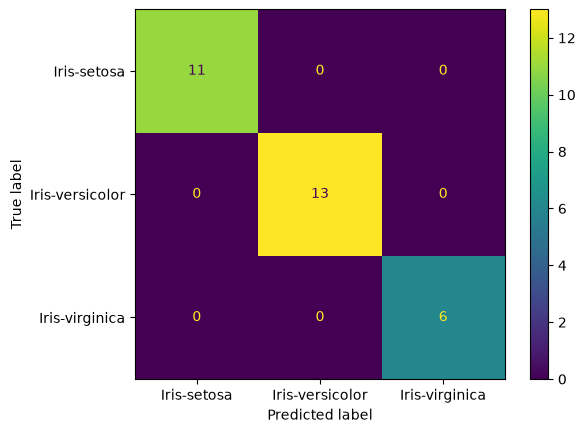

In [9]:
from sklearn.metrics import confusion_matrix
# https://scikit-learn.org/stable/modules/generated/sklearn.metrics.confusion_matrix.html

print(confusion_matrix(y_test, y_pred))

from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_predictions(y_test, y_pred)
plt.show()